oriC

GC Skew = (G - C) / (G + C) 

In [5]:
import matplotlib.pyplot as plt

# A 100-base dummy sequence with a hidden "flip" in the middle
dna_genome = "CCCCCATATCCCCCATATCCCCCATATCCCCCATATCC" + "GGGGGATATGGGGGATATGGGGGATATGGGGGATATGG"

print(f"Genome length: {len(dna_genome)}")

Genome length: 76


In [14]:
def calculate_gc_skew(sequence, window_size):
    """Calculates GC skew across a sequence using a sliding window."""
    skew_values = []
    
    # Slide the window across the sequence
    for i in range(len(sequence) - window_size + 1):
        window = sequence[i : i + window_size]
        
        g_count = window.count('G')
        c_count = window.count('C')
        
        # Prevent division by zero if a window has no Gs or Cs!
        if (g_count + c_count) == 0:
            skew_values.append(0)
        else:
            # The GC Skew Formula
            skew = (g_count - c_count) / (g_count + c_count)
            skew_values.append(skew)
            
    return skew_values

# Let's run it with a window size of 10
skew_data = calculate_gc_skew(dna_genome, window_size=10)
print(f"Calculated {len(skew_data)} skew data points!")

Calculated 67 skew data points!


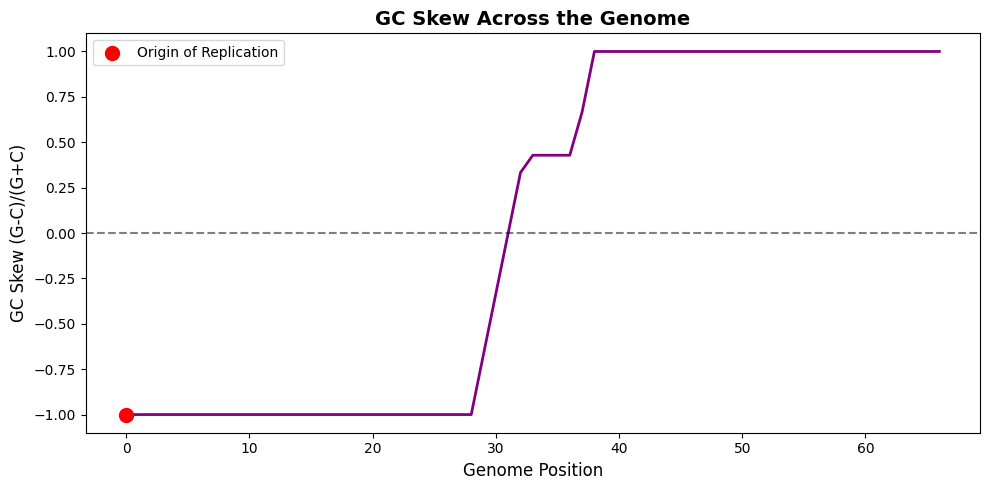

In [15]:
# Create the visualization
plt.figure(figsize=(10, 5))

# Plot the skew values
plt.plot(skew_data, color='purple', linewidth=2)

# Add a horizontal line at Y=0 for reference
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# Find and mark the exact minimum point (The Origin!)
min_skew = min(skew_data)
min_index = skew_data.index(min_skew)

# Draw a red dot exactly where the start button is
plt.scatter(min_index, min_skew, color='red', s=100, zorder=5, label='Origin of Replication')

# Labels and Title
plt.title("GC Skew Across the Genome", fontsize=14, fontweight='bold')
plt.xlabel("Genome Position", fontsize=12)
plt.ylabel("GC Skew (G-C)/(G+C)", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()